# Day 8 -- Local model benchmark (Ollama)

Compares `qwen2.5:7b` (current baseline) against `qwen3:14b` (and optionally `qwen3.5:9b`) using
realistic prompts from your Proposer/Critic roles (same style as `dia4`/`dia5`), measuring:

- **Latency** per call (seconds)
- **Tokens/second** (real throughput, not just generation speed)
- **Correct JSON parse rate** (reliability of the structured output)

The goal is to decide, with data rather than just the model's spec sheet, which one to use for
the full experiment grid (seeds x architectures x iterations).

**Before running this:**
1. Make sure you have downloaded the models you want to compare (`ollama pull qwen3:14b`, etc.)
2. Raise `OLLAMA_KEEP_ALIVE` if you'll take a while reviewing results between cells:
   `$env:OLLAMA_KEEP_ALIVE="30m"` in PowerShell before launching Jupyter/PyCharm.
3. Close other heavy apps (Chrome with many tabs, etc.) so they don't skew the VRAM/RAM measurement.


In [1]:
import ollama
import json
import time
import statistics
import pandas as pd
import matplotlib.pyplot as plt


## 1. Configuration

Comment/uncomment the models you have downloaded. `N_REPEATS` controls how many times each
model is called per role -- 15-20 repeats already gives a reasonable estimate of mean and
variance without taking too long.

In [2]:
MODELS = [
    'qwen2.5:7b',   # baseline actual
    'qwen3:14b',    # candidato principal
    # 'qwen3.5:9b', # uncomment if you downloaded it as a fallback
]

N_REPEATS = 15          # llamadas por modelo y por rol (sube a 30 si tienes tiempo)
NUM_CTX = 8192           # contexto explícito (por defecto Ollama carga 4096; súbelo si tu
                          # experiment history + system prompt is long)


## 2. Representative prompts

Same pattern used in `dia4`/`dia5`: an experiment history simulating ~8 iterations already run
(so the prompt has a realistic size, not a trivial 1-line case), a Proposer `system_prompt`,
and your two-layer Critic's `CRITIC_PROMPT_V2`.

In [3]:
def formatear_historial_dummy(n=8):
    """Genera un historial sintético de tamaño realista para no medir con un prompt trivial."""
    historial = ""
    base = {"temperature": 82.3, "pH": 7.3, "concentration": 1.05, "yield": 74.2}
    for i in range(n):
        historial += (
            f"Experiment {i+1}: Temperature={base['temperature']+i*1.1:.1f}\u00baC, "
            f"pH={base['pH']+0.05*i:.2f}, Concentration={base['concentration']+0.02*i:.2f}M, "
            f"yield={base['yield']+0.8*i:.2f}%\n"
        )
    return historial


PROPOSER_SYSTEM_PROMPT = """You are an expert chemist proposing the next experiment in a
Bayesian optimization campaign for a cross-coupling reaction. You will be shown the experiment
history and a candidate point suggested by the numerical optimizer (BoTorch). Enrich or adjust
this proposal with your chemical reasoning, staying within the given bounds.

Respond ONLY with a valid JSON object:
{
    "temperature": <float>,
    "pH": <float>,
    "concentration": <float>,
    "reasoning": "<string, 1-3 sentences>"
}
No additional text, no markdown."""

CRITIC_PROMPT_V2 = """You are a rigorous chemistry expert reviewing an experimental
proposal. The proposal has ALREADY passed automated safety and feasibility checks
(bounds and redundancy are verified separately and are NOT your concern).

Your ONLY job is to evaluate whether the chemical reasoning provided is coherent,
plausible, and consistent with the experimental history. Reject only if the
reasoning is contradictory, nonsensical, or unsupported by the data shown.

Respond ONLY with a valid JSON object:
{
    "approved": <true or false>,
    "rejection_reason": "<string if rejected, else null>",
    "concern_level": "<low|medium|high>"
}
No additional text, no markdown."""

historial_txt = formatear_historial_dummy()

PROPOSER_USER_MSG = (
    historial_txt
    + "\nBoTorch proposes the following candidate: temperature=88.40\u00baC, pH=7.60, "
      "concentration=1.15M. Evaluate it."
)

CRITIC_USER_MSG = (
    historial_txt
    + "\nProposed experiment: temperature=88.4, pH=7.60, concentration=1.15. "
      "Reasoning given: Slightly higher temperature and concentration should push yield further "
      "based on the upward trend observed in the last three experiments, while pH stays within "
      "the previously successful range.\n"
      "Evaluate the coherence of this reasoning."
)

PROMPTS = {
    "proposer": (PROPOSER_SYSTEM_PROMPT, PROPOSER_USER_MSG),
    "critic":   (CRITIC_PROMPT_V2, CRITIC_USER_MSG),
}


## 3. JSON parsing (same as your other notebooks) and single-call benchmark function

In [4]:
def parsear_respuesta(raw):
    clean = raw.strip()
    if clean.startswith("```"):
        clean = clean.split("```")[1]
        if clean.startswith("json"):
            clean = clean[4:]
    return json.loads(clean.strip())


def benchmark_una_llamada(model, system_prompt, user_msg, num_ctx=NUM_CTX, think=False):
    """Hace una llamada y devuelve métricas de tiempo/tokens/parseo.

    Usa los campos que Ollama devuelve en la respuesta (eval_count, eval_duration en
    nanosegundos) para calcular tokens/segundo reales de generación, sin contar el tiempo
    de carga del modelo si ya estaba caliente en memoria.

    `think=False` desactiva el modo de razonamiento oculto de los modelos híbridos
    (Qwen3, Qwen3.5, DeepSeek-R1...). Sin esto, estos modelos pueden generar cientos o miles
    de tokens de "pensamiento" interno antes de la respuesta final, inflando muchisimo la
    latencia aunque el prompt pida una salida corta. Si el modelo no soporta el parametro
    `think`, se reintenta automaticamente sin el.
    """
    t0 = time.perf_counter()
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_msg},
    ]
    try:
        try:
            respuesta = ollama.chat(
                model=model, messages=messages, think=think,
                options={"num_ctx": num_ctx},
            )
        except TypeError:
            # Old version of the ollama client without support for `think`
            respuesta = ollama.chat(
                model=model, messages=messages, options={"num_ctx": num_ctx},
            )
    except Exception as e:
        return {
            "model": model, "wall_time_s": time.perf_counter() - t0,
            "tokens_per_s": None, "parse_ok": False, "error": str(e),
        }
    wall_time = time.perf_counter() - t0

    raw = respuesta["message"]["content"]
    eval_count = respuesta.get("eval_count")
    eval_duration_ns = respuesta.get("eval_duration")
    tokens_per_s = (
        eval_count / (eval_duration_ns / 1e9)
        if eval_count and eval_duration_ns else None
    )

    try:
        parsear_respuesta(raw)
        parse_ok = True
        error = None
    except Exception as e:
        parse_ok = False
        error = f"JSON parse error: {e}"

    return {
        "model": model,
        "wall_time_s": wall_time,
        "tokens_per_s": tokens_per_s,
        "eval_count": eval_count,
        "parse_ok": parse_ok,
        "error": error,
    }


### Important note: "thinking" mode in hybrid models

If you already ran an earlier version of this notebook and `qwen3:14b` came out abnormally
slow (much more than the CPU/GPU split you saw in `ollama ps` would explain), it's almost
certainly because the model was generating an extremely long hidden reasoning trace before
the final response ("thinking" mode, enabled by default in Qwen3/Qwen3.5/DeepSeek-R1).
This can multiply the number of tokens generated per call by 10-20x, even though the
prompt explicitly asks for a short output.

The `benchmark_una_llamada` function below already calls with `think=False` by default, with
an automatic fallback if your version of the Ollama client doesn't support the parameter
(update with `pip install -U ollama` if you see the fallback trigger).

## 4. Run the benchmark

A "warm-up" first per model (so the first model isn't penalised with VRAM/RAM loading time),
then `N_REPEATS` calls per role.

In [5]:
resultados = []

for model in MODELS:
    print(f"\n{'='*60}\nModelo: {model}\n{'='*60}")

    # Warm-up: loads the model into memory without counting this time in the metrics
    print("  Warming up...")
    _ = benchmark_una_llamada(model, *PROMPTS["proposer"])

    for rol, (system_prompt, user_msg) in PROMPTS.items():
        print(f"  Rol: {rol}  ({N_REPEATS} llamadas)")
        for i in range(N_REPEATS):
            r = benchmark_una_llamada(model, system_prompt, user_msg)
            r["rol"] = rol
            r["intento"] = i + 1
            resultados.append(r)
            estado = "OK" if r["parse_ok"] else "FALLO JSON"
            tps = f"{r['tokens_per_s']:.1f} tok/s" if r["tokens_per_s"] else "N/A"
            print(f"    [{i+1}/{N_REPEATS}] {r['wall_time_s']:.2f}s | {tps} | {estado}")

df = pd.DataFrame(resultados)
df.to_csv("model_benchmark_results.csv", index=False)
df.head()



Modelo: qwen2.5:7b
  Warming up...
  Rol: proposer  (15 llamadas)
    [1/15] 3.20s | 44.3 tok/s | OK
    [2/15] 2.74s | 43.2 tok/s | OK
    [3/15] 3.65s | 42.6 tok/s | OK
    [4/15] 2.41s | 44.5 tok/s | OK
    [5/15] 3.00s | 44.3 tok/s | OK
    [6/15] 3.13s | 44.0 tok/s | OK
    [7/15] 2.79s | 42.2 tok/s | OK
    [8/15] 3.17s | 44.6 tok/s | OK
    [9/15] 3.24s | 46.7 tok/s | OK
    [10/15] 2.77s | 43.4 tok/s | OK
    [11/15] 2.84s | 47.2 tok/s | OK
    [12/15] 2.32s | 46.4 tok/s | OK
    [13/15] 2.77s | 47.2 tok/s | OK
    [14/15] 2.75s | 46.6 tok/s | OK
    [15/15] 2.52s | 45.7 tok/s | OK
  Rol: critic  (15 llamadas)
    [1/15] 1.58s | 45.8 tok/s | OK
    [2/15] 1.44s | 44.0 tok/s | OK
    [3/15] 1.35s | 49.7 tok/s | OK
    [4/15] 1.51s | 49.4 tok/s | OK
    [5/15] 1.28s | 46.5 tok/s | OK
    [6/15] 1.27s | 50.6 tok/s | OK
    [7/15] 1.84s | 49.7 tok/s | OK
    [8/15] 1.98s | 47.3 tok/s | OK
    [9/15] 2.10s | 47.8 tok/s | OK
    [10/15] 2.00s | 50.3 tok/s | OK
    [11/15] 2.00s | 47

,model,wall_time_s,tokens_per_s,eval_count,parse_ok,error,rol,intento
0,qwen2.5:7b,3.200307,44.296863,106,True,None,proposer,1
1,qwen2.5:7b,2.743539,43.168462,84,True,None,proposer,2
2,qwen2.5:7b,3.653613,42.585659,120,True,None,proposer,3
3,qwen2.5:7b,2.407725,44.474005,67,True,None,proposer,4
4,qwen2.5:7b,3.001229,44.272907,96,True,None,proposer,5


## 5. Aggregate summary

In [6]:
resumen = df.groupby(["model", "rol"]).agg(
    latencia_media_s=("wall_time_s", "mean"),
    latencia_std_s=("wall_time_s", "std"),
    tokens_s_media=("tokens_per_s", "mean"),
    tokens_s_std=("tokens_per_s", "std"),
    tasa_exito_json=("parse_ok", "mean"),
    n=("wall_time_s", "count"),
).round(2)

resumen["tasa_exito_json"] = (resumen["tasa_exito_json"] * 100).round(1)
print(resumen.to_string())
resumen.to_csv("model_benchmark_summary.csv")


                     latencia_media_s  latencia_std_s  tokens_s_media  tokens_s_std  tasa_exito_json   n
model      rol                                                                                          
qwen2.5:7b critic                1.76            0.32           47.47          2.22            100.0  15
           proposer              2.89            0.35           44.85          1.67            100.0  15
qwen3:14b  critic                4.29            0.29            8.85          0.64            100.0  15
           proposer             12.10            0.93            8.67          0.04            100.0  15


## 6. Comparison chart

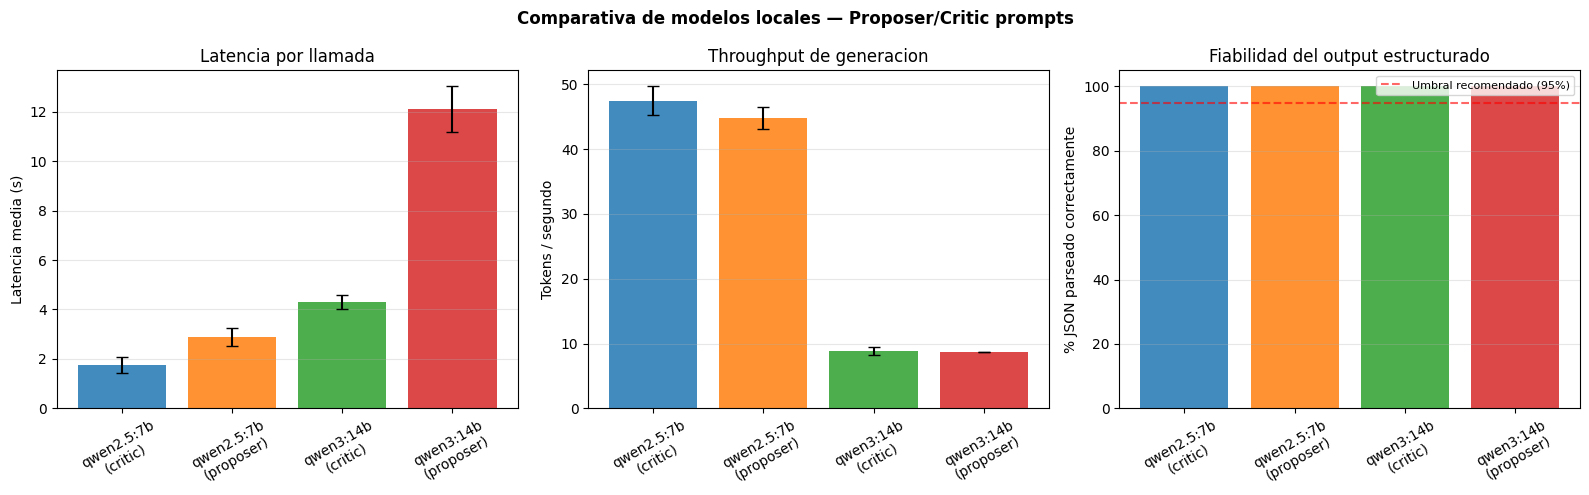

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Comparativa de modelos locales — Proposer/Critic prompts", fontweight="bold")

resumen_flat = resumen.reset_index()
resumen_flat["label"] = resumen_flat["model"] + "\n(" + resumen_flat["rol"] + ")"

colores = plt.cm.tab10(range(len(resumen_flat)))

axes[0].bar(resumen_flat["label"], resumen_flat["latencia_media_s"],
            yerr=resumen_flat["latencia_std_s"], color=colores, alpha=0.85, capsize=4)
axes[0].set_ylabel("Latencia media (s)")
axes[0].set_title("Latencia por llamada")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(resumen_flat["label"], resumen_flat["tokens_s_media"],
            yerr=resumen_flat["tokens_s_std"], color=colores, alpha=0.85, capsize=4)
axes[1].set_ylabel("Tokens / segundo")
axes[1].set_title("Throughput de generacion")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(alpha=0.3, axis="y")

axes[2].bar(resumen_flat["label"], resumen_flat["tasa_exito_json"], color=colores, alpha=0.85)
axes[2].axhline(y=95, color="red", linestyle="--", alpha=0.6, label="Umbral recomendado (95%)")
axes[2].set_ylabel("% JSON parseado correctamente")
axes[2].set_title("Fiabilidad del output estructurado")
axes[2].set_ylim(0, 105)
axes[2].tick_params(axis="x", rotation=30)
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("model_benchmark_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. How to read this and decide

As a rough guide (adjust based on how many calls per BO iteration you need and how many
seeds/architectures you plan to run):

- **JSON success rate < 95%** for any model: discard it or add retries with backoff before
  using it in the full grid -- a single `KeyError` halfway through a 30-iteration campaign can
  ruin the entire run.
- **Tokens/second**: with the plan's core grid (10 seeds x 4 methods x ~30 iterations x
  ~3-4 calls per iteration) you can estimate the total approximate time:
  `total_time_h = (10*4*30*3.5 * tokens_per_response) / (tokens_per_s * 3600)`
  With `tokens_per_response` ~120-200 (short JSON responses), compare the result across
  models to see whether `qwen3:14b` is still viable in the time left before the
  write-up, or whether it's better to keep a faster model for the core grid and reserve
  the larger one only for the model-scale ablation (section 8 of the research plan).
- If you see a `PROCESSOR` with high CPU offload (like the 37%/63% you observed with
  `ollama ps`) and throughput drops a lot, try `qwen3.5:9b` as an alternative that should
  fit entirely in your 8GB of VRAM.

Save `model_benchmark_summary.csv` and `model_benchmark_comparison.png` -- they can be used
directly as a methodology table/figure in the thesis (the "local model choice" section).

## 8. (Optional) Real cost of "thinking" mode

If you want to quantify how much thinking mode costs in tokens/latency for your own
report (or you want to leave it deliberately enabled for the batch-selection reasoning
agent in section 5 of the plan, where you DO want it to "think"), this cell compares
`think=True` vs `think=False` on the same model and prompt. Adjust `MODELO_THINKING_TEST`
to the model you want to diagnose.

In [8]:
MODELO_THINKING_TEST = "qwen3:14b"
N_REPEATS_THINKING = 8

resultados_thinking = []
for think_flag in [True, False]:
    print(f"think={think_flag}")
    for i in range(N_REPEATS_THINKING):
        r = benchmark_una_llamada(
            MODELO_THINKING_TEST, *PROMPTS["critic"], think=think_flag
        )
        r["think"] = think_flag
        resultados_thinking.append(r)

df_thinking = pd.DataFrame(resultados_thinking)
resumen_thinking = df_thinking.groupby("think").agg(
    latencia_media_s=("wall_time_s", "mean"),
    tokens_generados_media=("eval_count", "mean"),
    tasa_exito_json=("parse_ok", "mean"),
).round(2)
print(resumen_thinking.to_string())


think=True
think=False
       latencia_media_s  tokens_generados_media  tasa_exito_json
think                                                           
False              3.92                   26.00              1.0
True             170.14                 1344.38              1.0
